In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib as mpl

import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Roboto"]
mpl.rcParams["figure.dpi"] = 100

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.3
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 12

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Roboto"],
    "font.size": 12,
    "axes.titleweight": "regular",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 16
})

In [49]:
def evolve(x0, y0, f, N=1, crit=0):
  traj = np.zeros((N+1, 8))
  traj[0] = np.array([*x0, *y0])
  x = x0
  y = y0

  for t in range(1, N+1):
    if t % 25 == 0:
        # print(f"LD at {t}: {x[0]*x[3]-x[1]*x[2] + y[0]*y[3]-y[1]*y[2]:.8f}")
        # print(f"LD at {t}: {(x[0]+y[0])*(x[3]+y[3])-(x[1]+y[1])*(x[2]+y[2]):.8f}")
        
        c=0.5
        s = 0.1
        R0 = 1-s/2
        w = np.array([R0, R0*(1-s), R0*(1-s), R0*(1+s)])
        w_bar = np.dot(x, w) + np.dot(y, w)
        Ds = (w[0]*w[3]*(x[0]+y[0])*(x[3]+y[3]) - w[1]*w[2]*(x[1]+y[1])*(x[2]+y[2])) / w_bar**2
        # print(f"Expected LD: {(1-c)*Ds:.8f}\n")
        
    if t == crit:
      # amt = 0.5
      # y = amt * x.copy()
      # x = (1-amt)* x
      amt = 0.001
      y[3]+=amt
      freq_total = x.sum() + y.sum()
      x /= freq_total
      y /= freq_total
      
    #   if t % 100 == 0:
    #       print(x, y)
    x, y = f(x, y)
    traj[t] = np.array([*x, *y])

  return traj

def plot_traj(traj, N_gen):
    generations = np.arange(traj.shape[0])
    labels = [r"$x_1$", r"$x_2$", r"$x_3$", r"$x_4$", r"$y_1$", r"$y_2$", r"$y_3$", r"$y_4$"]
    colors = ['navy', 'forestgreen', 'purple', 'crimson']

    fig, ax = plt.subplots(1, 1, figsize=(8,5))
    for i in range(4):
        plt.plot(generations, traj[:, i], label=labels[i], color=colors[i], alpha=0.7)
    for i in range(4):
        plt.plot(generations, traj[:, i+4], label=labels[i+4], color=colors[i], alpha=0.7, ls='--')

    plt.ylim(-0.05, 1.05)
    plt.xlim(0, N_gen)
    plt.ylabel('Frequency')
    plt.xlabel('Generation')
    plt.title(r'Invasion with $r_{12}=r_{22}=0.05$, $r=0.01$') # for $r_{12}=r_{22}=0.05$ with Invasion of $M_2$ into $M_1$
    plt.legend()
    plt.show()

def evolve_traj(f, x_init=np.zeros(4), y_init=np.zeros(4), N_gen=2000):
  traj = evolve(x_init, y_init, f, N_gen)
  plot_traj(traj, N_gen)
  return traj

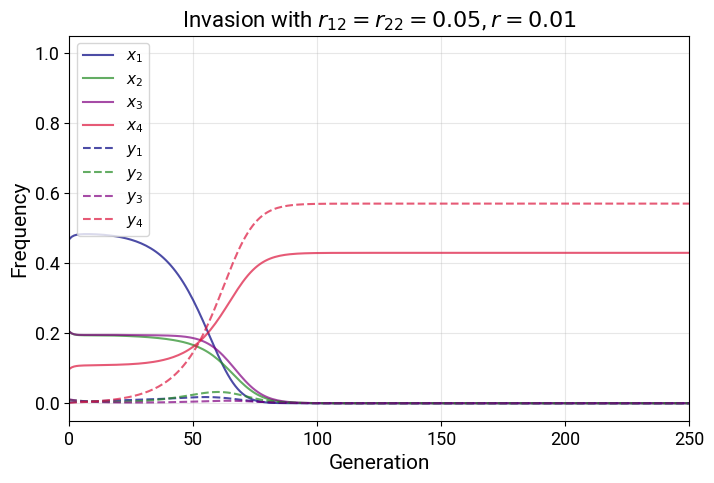

In [50]:
def f(x, y):
  s = 0.1
  R0 = 1-s/2
  w = np.array([R0, R0*(1-s), R0*(1-s), R0*(1+s)])
  w_bar = np.dot(x, w) + np.dot(y, w)
  
  r_11 = 0.5
  r_22 = 0.05
  r_12 = 0.05 # 0.5*(r_1 + r_2)
  r = 0.01

  # 0: ab, 1: Ab, 2: aB, 3: AB
  # x: modifier m, y: modifier M
  x_prime = np.zeros(4)
  y_prime = np.zeros(4)
  
  cross_loss_indices = [
    [1, 2, 3, 3],  # abm with AbM, abM, ABM
    [0, 3, 2, 2],  # Abm with abM, ABM, aBM
    [3, 0, 1, 1],  # aBm with ABM, abM, AbM
    [2, 1, 0, 0],  # ABm with aBM, AbM, abM
  ]

  # x[i] * y[j]
  cross_gain_pairs = [
    [(1,2), (1,0), (2,1), (2, 0)], # ab
    [(0,3), (0,1), (3,0), (3,1)], # Ab
    [(3,0), (3,2), (0,3), (0,2)], # aB
    [(2,1), (2,3), (1,2), (1,3)] # AB
  ]

  x = x*w / w_bar
  y = y*w / w_bar
  
  for i in range(4):
    # Recombination within same modifier allele
    sgn_wtn = 1 if i in [0,3] else -1
    reco_ab_wtn = sgn_wtn * r_11 * (x[0]*x[3] - x[1]*x[2])

    # Recombination between the A and B loci
    il = (i + 2) % 4
    i1 = min(i, il)
    i2 = max(i, il)
    sgn_btwn = -1 if i in [2, 3] else 1
    reco_ab_between = sgn_btwn * r_12 * (x[i1] * (y[2] + y[3]) - x[i2] * (y[0] + y[1]))
    
    # Recombination between the B and M loci
    # reco_bm = r * (sum([x[i] * y[j] for j in range(4) if j != i]) - sum([y[i] * x[j] for j in range(4) if j != i]))
    reco_bm = r * (x[i] * (y.sum() - y[i]) - y[i] * (x.sum() - x[i]))
    
    # Recombination and accounting between both pairs of adjacent loci
    ia = i - 1 if i%2==1 else i + 1
    reco_double = r * r_12 * (2*x[i]*y[il] - 2*x[il]*y[i] + x[i]*y[3-i] + x[ia]*y[3-ia] - x[3-i]*y[i] - x[3-ia]*y[ia])
    
    x_prime[i] = x[i] - reco_ab_wtn - reco_ab_between - reco_bm + reco_double
    
    # # Old code without r
    # loss = -0.5 * r_h * [x[i] * y[cross_loss_indices[i]]].sum()
    # gain = 0.5 * r_h * sum(x[j]*y[k] for (j,k) in cross_gain_pairs[i])
    # gain_brute = cross_recombination_gain(x, y, r_h)

    # x_prime[i] = x[i] + within + loss + gain
  
  for i in range(4):
    # Recombination within same modifier allele
    sgn_wtn = 1 if i in [0,3] else -1
    reco_ab_wtn = sgn_wtn * r_22 * (y[0]*y[3] - y[1]*y[2])

    # Recombination between the A and B loci
    il = (i + 2) % 4
    i1 = min(i, il)
    i2 = max(i, il)
    sgn_btwn = -1 if i in [2, 3] else 1
    reco_ab_between = sgn_btwn * r_12 * (y[i1] * (x[2] + x[3]) - y[i2] * (x[0] + x[1]))
    
    # Recombination between the B and M loci
    reco_bm = r * (y[i] * (x.sum() - x[i]) - x[i] * (y.sum() - y[i]))
    
    # Recombination and accounting between both pairs of adjacent loci
    ia = i - 1 if i%2==1 else i + 1
    reco_double = r * r_12 * (2*y[i]*x[il] - 2*y[il]*x[i] + y[i]*x[3-i] + y[ia]*x[3-ia] - y[3-i]*x[i] - y[3-ia]*x[ia])
    
    y_prime[i] = y[i] - reco_ab_wtn - reco_ab_between - reco_bm + reco_double
    
    # # Old code without r
    # sgn = -1 if i in [0,3] else 1
    # within = sgn * r_2 * (y[0]*y[3] - y[1]*y[2])
    # loss = -0.5 * r_h * y[i] * x[cross_loss_indices[i]].sum()
    # gain = 0.5 * r_h * sum(y[j]*x[k] for (j,k) in cross_gain_pairs[i])

    # y_prime[i] = y[i] + within + loss + gain
  
  np.allclose(x_prime.sum(), x.sum())
  np.allclose(y_prime.sum(), y.sum())
  np.allclose((x_prime + y_prime).sum(), (x + y).sum())
  return x_prime, y_prime

# Initialization
x1 = 0.48
x4 = 0.1
x2 = (1 - x1 - x4) / 2
x3 = x2

total = 0.025
y_r = np.random.dirichlet(np.ones(4)) * total


x_init = np.array([x1, x2, x3, x4])
y_init = np.array(y_r)

# Normalization
freq_total = x_init.sum() + y_init.sum()
x_init /= freq_total
y_init /= freq_total



plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Roboto"],
    "font.size": 14,
    "axes.titleweight": "regular",
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 11,
    "figure.titlesize": 16
})

traj = evolve_traj(f, x_init, y_init, 250)

In [ ]:
x1 = 0.5
x4 = 0.1
x2 = (1 - x1 - x4) / 2
x3 = x2
x_init = np.array([x1-0.001, x2, x3, x4])
y_init = np.array([0.0, 0.001, 0.0, 0.0])

/Users/chasevanamburg/miniforge3/envs/mf/lib/python3.13/site-packages/matplotlib/patches.py:3436: RuntimeWarning: invalid value encountered in scalar divide
  cos_t, sin_t = head_length / head_dist, head_width / head_dist


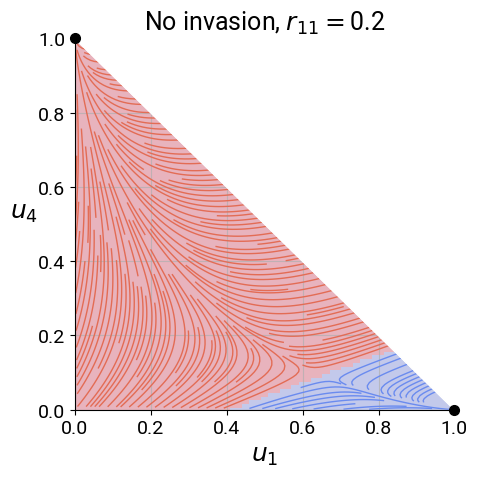

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.patches import Polygon

y_total = 0.0
r_1 = 0.2
r_2 = 0.4
rM = 0.1

def f(x, y):
  s = 0.1
  R0 = 1-s/2
  w = np.array([R0, R0*(1-s), R0*(1-s), R0*(1+s)])
  w_bar = np.dot(x, w) + np.dot(y, w)
  
  r_11 = r_1
  r_22 = r_2
  r_12 = r_2 # 0.5*(r_1 + r_2)
  r = rM

  # 0: ab, 1: Ab, 2: aB, 3: AB
  # x: modifier , y: modifier M
  x_prime = np.zeros(4)
  y_prime = np.zeros(4)

  x = x*w / w_bar
  y = y*w / w_bar
  
  for i in range(4):
    # Recombination within same modifier allele
    sgn_wtn = 1 if i in [0,3] else -1
    reco_ab_wtn = sgn_wtn * r_11 * (x[0]*x[3] - x[1]*x[2])

    # Recombination between the A and B loci
    il = (i + 2) % 4
    i1 = min(i, il)
    i2 = max(i, il)
    sgn_btwn = -1 if i in [2, 3] else 1
    reco_ab_between = sgn_btwn * r_12 * (x[i1] * (y[2] + y[3]) - x[i2] * (y[0] + y[1]))
    
    # Recombination between the B and M loci
    reco_bm = r * (x[i] * (y.sum() - y[i]) - y[i] * (x.sum() - x[i]))
    
    # Recombination and accounting between both pairs of adjacent loci
    ia = i - 1 if i%2==1 else i + 1
    reco_double = r * r_12 * (2*x[i]*y[il] - 2*x[il]*y[i] + x[i]*y[3-i] + x[ia]*y[3-ia] - x[3-i]*y[i] - x[3-ia]*y[ia])
    
    x_prime[i] = x[i] - reco_ab_wtn - reco_ab_between - reco_bm + reco_double
  
  for i in range(4):
    # Recombination within same modifier allele
    sgn_wtn = 1 if i in [0,3] else -1
    reco_ab_wtn = sgn_wtn * r_22 * (y[0]*y[3] - y[1]*y[2])

    # Recombination between the A and B loci
    il = (i + 2) % 4
    i1 = min(i, il)
    i2 = max(i, il)
    sgn_btwn = -1 if i in [2, 3] else 1
    reco_ab_between = sgn_btwn * r_12 * (y[i1] * (x[2] + x[3]) - y[i2] * (x[0] + x[1]))
    
    # Recombination between the B and M loci
    reco_bm = r * (y[i] * (x.sum() - x[i]) - x[i] * (y.sum() - y[i]))
    
    # Recombination and accounting between both pairs of adjacent loci
    ia = i - 1 if i%2==1 else i + 1
    reco_double = r * r_12 * (2*y[i]*x[il] - 2*y[il]*x[i] + y[i]*x[3-i] + y[ia]*x[3-ia] - y[3-i]*x[i] - y[3-ia]*x[ia])
    
    y_prime[i] = y[i] - reco_ab_wtn - reco_ab_between - reco_bm + reco_double
  
  return x_prime, y_prime

def evolve(x0, f, N=200):
  traj = np.zeros((N+1, 8))
  
  total = y_total
  y0 = np.random.dirichlet(np.ones(4)) * total
  freq_total = x0.sum() + y0.sum()
  x = x0 / freq_total
  y = y0 / freq_total
  
  traj[0] = np.array([*x0, *y0])

  for t in range(1, N+1):
    x, y = f(x, y)
    traj[t] = np.array([*x, *y])

  return traj

init_points = [ ]
grid = np.linspace(0.02, 0.98, 100)
for x1 in grid:
    for x4 in grid:
        if x1+x4 <= 1:
            x2 = (1-x1-x4)/2
            x3 = x2
            x = np.array([x1, x2, x3, x4])
            init_points.append(x)
final_points = np.array([evolve(x, f)[-1] for x in init_points])
kmeans = KMeans(n_clusters=2, n_init=10, random_state=0).fit(np.array([final_points[:, 0] + final_points[:, 4], final_points[:, 3] + final_points[:, 7]]).T)
centers = kmeans.cluster_centers_


n = 100
x1_flat = np.linspace(0.0, 1.0, n)
x4_flat = x1_flat.copy()
x1s, x4s = np.meshgrid(x1_flat, x4_flat)
mask = (x1s + x4s) <= 1.0
x1s_masked = np.ma.masked_where(~mask, x1s)
x4s_masked = np.ma.masked_where(~mask, x4s)

delta_x1 = np.zeros_like(x1s)
delta_x4 = np.zeros_like(x4s)

basin_labels = np.zeros_like(x1s, dtype=int)

for i in range(n):
    for j in range(n):
        x1, x4 = x1s[i, j], x4s[i, j]
        x2 = (1 - x1 - x4) / 2
        x3 = x2
        x = np.array([x1, x2, x3, x4])
        y = np.random.dirichlet(np.ones(4)) * y_total
        freq_total = x.sum() + y.sum()
        x_prime, y_prime = f(x/freq_total, y/freq_total)
        for k in range(3):
          x_prime, y_prime = f(x_prime, y_prime)
        delta_x1[i, j] = x_prime[0] + y_prime[0] - (x[0] + y[0])
        delta_x4[i, j] = x_prime[3] + y_prime[3] - (x[3] + y[3])
        
        x_f = evolve(x, f)[-1]
        basin_labels[i, j] = kmeans.predict([[x_f[0] + x_f[4], x_f[3] + x_f[7]]])[0]


fig, ax = plt.subplots(figsize=(5, 5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel(r"$u_1$")
ax.set_ylabel(r"$u_4$", rotation=0, labelpad=10)
ax.grid(True, alpha=0.7)

basin_labels = 1 - basin_labels
ax.pcolormesh(x1s, x4s, basin_labels, cmap="coolwarm", shading="auto", alpha=0.3, vmin=0, vmax=1)
color_map = [plt.cm.coolwarm(0.15), plt.cm.coolwarm(0.85)]

for label, color in enumerate(color_map):
    delta_x1_masked = np.ma.masked_where(basin_labels != label, delta_x1)
    delta_x4_masked = np.ma.masked_where(basin_labels != label, delta_x4)
    # delta_x1_masked = np.ma.masked_where(~mask, delta_x1_masked)
    # delta_x4_masked = np.ma.masked_where(~mask, delta_x4_masked)

    strm = ax.streamplot(x1s, x4s, delta_x1_masked, delta_x4_masked, color=color, density=3, linewidth=1, arrowsize=0, integration_direction="forward")
    triangle = Polygon(
        [(0, 0), (1, 0), (0, 1)],
        closed=True,
        transform=ax.transData
    )
    strm.lines.set_clip_path(triangle)
    strm.arrows.set_clip_path(triangle)
    ax.fill(
        [0, 1, 1],
        [1, 0, 1],
        color="white",
        zorder=3
    )

ax.plot(centers[:, 0], centers[:, 1], 'ko', markersize=7, label="Equilibria", clip_on=False, zorder=10) # centers[1:, 0], centers[1:, 1]
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
title1 = (
    r"Invasion, $r_{11}=$"
    f"{r_1} "
    r", $r_{12}=r_{22}=$"
    f"{r_2} "
)
title2 = r"No invasion, $r_{11}=$" + str(r_1)
title = title1 if y_total > 0 else title2 
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Roboto"],
    "font.size": 14,
    "axes.titleweight": "regular",
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 11,
    "figure.titlesize": 16
})
plt.title(title); plt.tight_layout(); plt.show() # , $r_{12}=r_{22}=0.4$
